# Medallion Architecture in 1200 Records  
## Bronze → Silver → Gold with DuckDB

This notebook teaches **Medallion Architecture** step by step using a small retail sales dataset with **1200 clean records**.

We will use three logical layers:

- **Bronze**: raw ingested data
- **Silver**: cleaned, standardized, typed data
- **Gold**: analytical model for reporting and BI

The source CSV contains the following columns:

- `sale_id`
- `sale_type`
- `product`
- `customer_name`
- `customer_email`
- `customer_country`
- `quantity`
- `unit_price`
- `discount`
- `store_location`
- `sale_date`

---

## Teaching Goal

By the end of this notebook, you will understand:

1. how raw data lands in Bronze  
2. how Silver improves quality and consistency  
3. how Gold prepares the data for analytics  
4. how to write analytical SQL on top of Gold tables


## Cell 1 — Import libraries and create a DuckDB connection

### What are we doing?
We import Python libraries and create a local DuckDB database connection.

### Why are we doing this?
DuckDB lets us build a small data warehouse directly inside a notebook.  
This is excellent for teaching because students can run SQL immediately without installing a separate database server.


In [1]:
import duckdb
import pandas as pd

con = duckdb.connect("medallion_1200.duckdb")
print("Connected to DuckDB.")


Connected to DuckDB.


## Cell 2 — Define the source file

### What are we doing?
We define the CSV file name that contains the 1200 sales records.

### Why are we doing this?
Keeping the file name in one variable makes the notebook easier to maintain.  
If the file changes later, students only need to update one place.


In [2]:
csv_file = "medallion_sales_1200.csv"
print("Using source file:", csv_file)


Using source file: medallion_sales_1200.csv


## Cell 3 — Preview the raw CSV with pandas

### What are we doing?
We load a small preview of the CSV file using pandas.

### Why are we doing this?
Before building Bronze, we should inspect the incoming data:
- column names
- sample values
- business meaning of the fields

This is the first step in understanding the raw source.


In [5]:
df_preview = pd.read_csv(csv_file)
df_preview.head(10)

,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date
0,1,ON-LINE,IPAD,Megan Carter,megan.carter83@outlook.com,USA,1,700,0.0,USA,06/21/2025
1,2,ON-LINE,IPAD,Kevin Johnson,kevin.johnson34@yahoo.com,USA,1,700,0.0,USA,11/08/2025
2,3,ON-LINE,COMPUTER,Rebecca White,rebecca.white18@proton.me,USA,1,1400,0.0,USA,11/23/2025
3,4,IN-STORE,WATCH,Jack Gonzalez,jack.gonzalez6@yahoo.com,GERMANY,2,250,60.0,USA,11/13/2025
4,5,ON-LINE,IPHONE,Ryan Jackson,ryan.jackson94@proton.me,CANADA,3,1100,396.0,CANADA,08/01/2025
5,6,IN-STORE,COMPUTER,Megan Wilson,megan.wilson17@outlook.com,CANADA,3,1400,210.0,ENGLAND,10/24/2025
6,7,IN-STORE,IPHONE,Jason Perez,jason.perez28@outlook.com,USA,1,1100,88.0,USA,01/11/2025
7,8,ON-LINE,IPAD,Jeffrey Parker,jeffrey.parker39@proton.me,MEXICO,2,700,0.0,ENGLAND,12/18/2025
8,9,ON-LINE,WATCH,George Stewart,george.stewart40@yahoo.com,ENGLAND,1,250,0.0,CANADA,04/15/2025
9,10,IN-STORE,COMPUTER,Bruce Taylor,bruce.taylor94@icloud.com,FRANCE,1,1400,112.0,USA,12/09/2025


In [6]:
df_preview.shape

(1200, 11)

## Cell 4 — Create logical schemas: Bronze, Silver, Gold

### What are we doing?
We create three schemas inside DuckDB.

### Why are we doing this?
Schemas help us separate layers clearly:

- `bronze` = ingestion layer
- `silver` = cleaned layer
- `gold` = reporting / analytics layer

Even in a small classroom example, this separation teaches a very important real-world habit.


In [7]:
con.execute("CREATE SCHEMA IF NOT EXISTS bronze;")
con.execute("CREATE SCHEMA IF NOT EXISTS silver;")
con.execute("CREATE SCHEMA IF NOT EXISTS gold;")

con.execute("SELECT schema_name FROM information_schema.schemata ORDER BY schema_name").df()


,schema_name
0,bronze
1,gold
2,information_schema
3,main
4,main
5,main
6,pg_catalog
7,silver


# Bronze Layer

The Bronze layer stores data as it arrives from the source.

In real systems, Bronze may contain:
- raw text
- inconsistent formatting
- duplicate rows
- missing values
- late-arriving data

In this notebook, the dataset is already clean, but we still use Bronze to teach the architecture correctly.


## Cell 5 — Create the Bronze table from the CSV file

### What are we doing?
We load the CSV file into `bronze.sales_raw`.

### Why are we doing this?
Bronze is the **landing zone**.  
It preserves the source data in its original form so that:
- we can trace where data came from
- we can reload Silver later
- we keep a reproducible ingestion step


In [8]:
con.execute("""
CREATE OR REPLACE TABLE bronze.sales_raw AS
SELECT *
FROM read_csv_auto('medallion_sales_1200.csv');
""")

con.execute("SELECT COUNT(*) AS bronze_row_count FROM bronze.sales_raw").df()


,bronze_row_count
0,1200


## Cell 6 — Inspect Bronze structure

### What are we doing?
We list the columns and data types in the Bronze table.

### Why are we doing this?
Bronze often reflects the source file more than the business model.  
We inspect structure before deciding what needs improvement in Silver.


In [9]:
con.execute("""
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'bronze'
  AND table_name = 'sales_raw'
ORDER BY ordinal_position;
""").df()

,column_name,data_type
0,sale_id,BIGINT
1,sale_type,VARCHAR
2,product,VARCHAR
3,customer_name,VARCHAR
4,customer_email,VARCHAR
5,customer_country,VARCHAR
6,quantity,BIGINT
7,unit_price,BIGINT
8,discount,DOUBLE
9,store_location,VARCHAR


In [10]:
# INSPECT metadata

con.execute("""
DESC TABLE bronze.sales_raw;
""").df()

,column_name,column_type,null,key,default,extra
0,sale_id,BIGINT,YES,None,None,None
1,sale_type,VARCHAR,YES,None,None,None
2,product,VARCHAR,YES,None,None,None
3,customer_name,VARCHAR,YES,None,None,None
4,customer_email,VARCHAR,YES,None,None,None
5,customer_country,VARCHAR,YES,None,None,None
6,quantity,BIGINT,YES,None,None,None
7,unit_price,BIGINT,YES,None,None,None
8,discount,DOUBLE,YES,None,None,None
9,store_location,VARCHAR,YES,None,None,None


## Cell 7 — Look at sample Bronze rows

### What are we doing?
We display sample rows from Bronze.

### Why are we doing this?
Students should connect SQL structure to actual business records:
- a customer
- a product
- a quantity
- a discount
- a sale date


In [11]:
con.execute("SELECT * FROM bronze.sales_raw LIMIT 10").df()


,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date
0,1,ON-LINE,IPAD,Megan Carter,megan.carter83@outlook.com,USA,1,700,0.0,USA,2025-06-21
1,2,ON-LINE,IPAD,Kevin Johnson,kevin.johnson34@yahoo.com,USA,1,700,0.0,USA,2025-11-08
2,3,ON-LINE,COMPUTER,Rebecca White,rebecca.white18@proton.me,USA,1,1400,0.0,USA,2025-11-23
3,4,IN-STORE,WATCH,Jack Gonzalez,jack.gonzalez6@yahoo.com,GERMANY,2,250,60.0,USA,2025-11-13
4,5,ON-LINE,IPHONE,Ryan Jackson,ryan.jackson94@proton.me,CANADA,3,1100,396.0,CANADA,2025-08-01
5,6,IN-STORE,COMPUTER,Megan Wilson,megan.wilson17@outlook.com,CANADA,3,1400,210.0,ENGLAND,2025-10-24
6,7,IN-STORE,IPHONE,Jason Perez,jason.perez28@outlook.com,USA,1,1100,88.0,USA,2025-01-11
7,8,ON-LINE,IPAD,Jeffrey Parker,jeffrey.parker39@proton.me,MEXICO,2,700,0.0,ENGLAND,2025-12-18
8,9,ON-LINE,WATCH,George Stewart,george.stewart40@yahoo.com,ENGLAND,1,250,0.0,CANADA,2025-04-15
9,10,IN-STORE,COMPUTER,Bruce Taylor,bruce.taylor94@icloud.com,FRANCE,1,1400,112.0,USA,2025-12-09


## Cell 8 — Profile the Bronze data

### What are we doing?
We calculate basic profiling metrics.

### Why are we doing this?
Data engineers always ask:
- How many rows do we have?
- Are IDs unique?
- How many customers and products exist?
- Are there obvious null issues?

This gives us a quick health check before Silver.


In [12]:
con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT sale_id) AS distinct_sale_ids,
    COUNT(DISTINCT customer_email) AS distinct_customers,
    COUNT(DISTINCT product) AS distinct_products,
    COUNT(DISTINCT sale_type) AS distinct_sale_types,
    COUNT(DISTINCT store_location) AS distinct_store_locations
FROM bronze.sales_raw;
""").df()


,total_rows,distinct_sale_ids,distinct_customers,distinct_products,distinct_sale_types,distinct_store_locations
0,1200,1200,100,6,2,3


# Silver Layer

The Silver layer improves the Bronze data.

Typical Silver tasks include:
- standardizing text
- converting data types
- validating business rules
- removing duplicates
- deriving useful columns

Even though this dataset is already valid, we still create Silver because it represents the **trusted and standardized** version of the data.


## Cell 9 — Create a cleaned and typed Silver table

### What are we doing?
We create `silver.sales_clean` by:
- uppercasing category-like fields
- trimming text fields
- converting `sale_date` to a real `DATE`
- keeping numeric fields in proper numeric types

### Why are we doing this?
Silver should be the reliable working layer for analysts and downstream transformations.


In [13]:
con.execute("""
CREATE OR REPLACE TABLE silver.sales_clean AS

SELECT

    CAST(sale_id AS INTEGER) AS sale_id,
    UPPER(TRIM(sale_type)) AS sale_type,
    UPPER(TRIM(product)) AS product,
    TRIM(customer_name) AS customer_name,
    LOWER(TRIM(customer_email)) AS customer_email,
    UPPER(TRIM(customer_country)) AS customer_country,
    CAST(quantity AS INTEGER) AS quantity,
    CAST(unit_price AS DOUBLE) AS unit_price,
    CAST(discount AS DOUBLE) AS discount,
    UPPER(TRIM(store_location)) AS store_location,
    CAST(sale_date AS DATE) AS sale_date

FROM bronze.sales_raw;
""")

con.execute("SELECT COUNT(*) AS silver_row_count FROM silver.sales_clean").df()


,silver_row_count
0,1200


## Cell 10 — Validate Silver data types

### What are we doing?
We inspect the schema of `silver.sales_clean`.

### Why are we doing this?
We want to verify that the transformations worked:
- `sale_date` should be a `DATE`
- quantity should be numeric
- price and discount should be numeric


In [14]:
# show me the metadata for silver.sales_clean table
con.execute("""
SELECT
    column_name,
    data_type
FROM information_schema.columns
WHERE table_schema = 'silver'
  AND table_name = 'sales_clean'
ORDER BY ordinal_position;
""").df()

,column_name,data_type
0,sale_id,INTEGER
1,sale_type,VARCHAR
2,product,VARCHAR
3,customer_name,VARCHAR
4,customer_email,VARCHAR
5,customer_country,VARCHAR
6,quantity,INTEGER
7,unit_price,DOUBLE
8,discount,DOUBLE
9,store_location,VARCHAR


In [15]:
# OR show me the metadata for silver.sales_clean table
con.execute("""
DESC TABLE silver.sales_clean;
""").df()

,column_name,column_type,null,key,default,extra
0,sale_id,INTEGER,YES,None,None,None
1,sale_type,VARCHAR,YES,None,None,None
2,product,VARCHAR,YES,None,None,None
3,customer_name,VARCHAR,YES,None,None,None
4,customer_email,VARCHAR,YES,None,None,None
5,customer_country,VARCHAR,YES,None,None,None
6,quantity,INTEGER,YES,None,None,None
7,unit_price,DOUBLE,YES,None,None,None
8,discount,DOUBLE,YES,None,None,None
9,store_location,VARCHAR,YES,None,None,None


## Cell 11 — Add derived business columns in Silver

### What are we doing?
We create a richer Silver table with derived measures:
- `gross_amount = quantity * unit_price`
- `net_amount = gross_amount - discount`
- year / month fields for time analysis

### Why are we doing this?
Derived fields reduce repeated SQL later and make Gold construction easier.


In [16]:
con.execute("""
CREATE OR REPLACE TABLE silver.sales_enriched AS
SELECT
    sale_id,
    sale_type,
    product,
    customer_name,
    customer_email,
    customer_country,
    quantity,
    unit_price,
    discount,
    store_location,
    sale_date,
    quantity * unit_price AS gross_amount,
    quantity * unit_price - discount AS net_amount,
    EXTRACT(YEAR FROM sale_date) AS sale_year,
    EXTRACT(MONTH FROM sale_date) AS sale_month,
    STRFTIME(sale_date, '%Y-%m') AS year_month
FROM silver.sales_clean;
""")

con.execute("SELECT * FROM silver.sales_enriched LIMIT 10").df()


,sale_id,sale_type,product,customer_name,customer_email,customer_country,quantity,unit_price,discount,store_location,sale_date,gross_amount,net_amount,sale_year,sale_month,year_month
0,1,ON-LINE,IPAD,Megan Carter,megan.carter83@outlook.com,USA,1,700.0,0.0,USA,2025-06-21,700.0,700.0,2025,6,2025-06
1,2,ON-LINE,IPAD,Kevin Johnson,kevin.johnson34@yahoo.com,USA,1,700.0,0.0,USA,2025-11-08,700.0,700.0,2025,11,2025-11
2,3,ON-LINE,COMPUTER,Rebecca White,rebecca.white18@proton.me,USA,1,1400.0,0.0,USA,2025-11-23,1400.0,1400.0,2025,11,2025-11
3,4,IN-STORE,WATCH,Jack Gonzalez,jack.gonzalez6@yahoo.com,GERMANY,2,250.0,60.0,USA,2025-11-13,500.0,440.0,2025,11,2025-11
4,5,ON-LINE,IPHONE,Ryan Jackson,ryan.jackson94@proton.me,CANADA,3,1100.0,396.0,CANADA,2025-08-01,3300.0,2904.0,2025,8,2025-08
5,6,IN-STORE,COMPUTER,Megan Wilson,megan.wilson17@outlook.com,CANADA,3,1400.0,210.0,ENGLAND,2025-10-24,4200.0,3990.0,2025,10,2025-10
6,7,IN-STORE,IPHONE,Jason Perez,jason.perez28@outlook.com,USA,1,1100.0,88.0,USA,2025-01-11,1100.0,1012.0,2025,1,2025-01
7,8,ON-LINE,IPAD,Jeffrey Parker,jeffrey.parker39@proton.me,MEXICO,2,700.0,0.0,ENGLAND,2025-12-18,1400.0,1400.0,2025,12,2025-12
8,9,ON-LINE,WATCH,George Stewart,george.stewart40@yahoo.com,ENGLAND,1,250.0,0.0,CANADA,2025-04-15,250.0,250.0,2025,4,2025-04
9,10,IN-STORE,COMPUTER,Bruce Taylor,bruce.taylor94@icloud.com,FRANCE,1,1400.0,112.0,USA,2025-12-09,1400.0,1288.0,2025,12,2025-12


## Cell 12 — Run Silver validation checks

### What are we doing?
We check a few business rules:
- no null primary sale IDs
- no duplicated sale IDs
- no negative quantity
- no negative unit price
- no negative discount
- no negative net amount

### Why are we doing this?
Silver is where we begin to trust the data.


In [17]:
con.execute("""
SELECT
    SUM(CASE WHEN sale_id IS NULL THEN 1 ELSE 0 END) AS null_sale_id,
    COUNT(*) - COUNT(DISTINCT sale_id) AS duplicate_sale_id_count,
    SUM(CASE WHEN quantity <= 0 THEN 1 ELSE 0 END) AS bad_quantity_count,
    SUM(CASE WHEN unit_price < 0 THEN 1 ELSE 0 END) AS bad_unit_price_count,
    SUM(CASE WHEN discount < 0 THEN 1 ELSE 0 END) AS bad_discount_count,
    SUM(CASE WHEN net_amount < 0 THEN 1 ELSE 0 END) AS bad_net_amount_count
FROM silver.sales_enriched;
""").df()


,null_sale_id,duplicate_sale_id_count,bad_quantity_count,bad_unit_price_count,bad_discount_count,bad_net_amount_count
0,0.0,0,0.0,0.0,0.0,0.0


## Cell 13 — Understand customer concentration in Silver

### What are we doing?
We identify the most active customers by transaction count.

### Why are we doing this?
The dataset was intentionally created so that some customers dominate.  
This confirms that the data is **not balanced**, which is useful for analytical practice.


In [18]:
con.execute("""
SELECT
    customer_name,
    customer_email,
    COUNT(*) AS purchase_count,
    ROUND(SUM(net_amount), 2) AS total_net_sales
FROM silver.sales_enriched
GROUP BY customer_name, customer_email
ORDER BY purchase_count DESC, total_net_sales DESC
LIMIT 10;
""").df()


,customer_name,customer_email,purchase_count,total_net_sales
0,Megan Carter,megan.carter83@outlook.com,292,473044.0
1,Kevin Johnson,kevin.johnson34@yahoo.com,130,200107.0
2,Rebecca White,rebecca.white18@proton.me,75,121285.0
3,Jack Gonzalez,jack.gonzalez6@yahoo.com,50,77559.5
4,Ryan Jackson,ryan.jackson94@proton.me,46,94403.0
5,Megan Wilson,megan.wilson17@outlook.com,42,67835.0
6,Grace Jackson,grace.jackson80@outlook.com,32,46186.0
7,Jeffrey Parker,jeffrey.parker39@proton.me,32,45650.0
8,Jason Perez,jason.perez28@outlook.com,32,42760.0
9,Bruce Taylor,bruce.taylor94@icloud.com,27,45175.0


# Gold Layer

The Gold layer is built for analytics, reporting, dashboards, and business questions.

In this notebook, we will build a small star schema:
- one fact table
- several dimension tables

This makes analytical SQL easier, cleaner, and more reusable.


## Cell 14 — Create `gold.dim_customer`

### What are we doing?
We create a customer dimension with one row per customer.

### Why are we doing this?
Dimensions store descriptive business entities.  
The customer dimension allows us to analyze sales by customer and country.

#### Now, we create `customer_key` to represent the following 3 columns:

* `customer_name`,
* `customer_email`,
* `customer_country`

Anytime we need a customer information, we use `customer_key`

In [19]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_customer AS
SELECT
    ROW_NUMBER() OVER (ORDER BY customer_email) AS customer_key,
    customer_name,
    customer_email,
    customer_country
FROM (
    SELECT DISTINCT
        customer_name,
        customer_email,
        customer_country
    FROM silver.sales_enriched
);
""")

con.execute("SELECT * FROM gold.dim_customer LIMIT 10").df()


,customer_key,customer_name,customer_email,customer_country
0,1,Amanda Wilson,amanda.wilson34@proton.me,ITALY
1,2,Amy Thomas,amy.thomas53@yahoo.com,GERMANY
2,3,Anna Martinez,anna.martinez28@gmail.com,USA
3,4,Anna Taylor,anna.taylor7@gmail.com,ENGLAND
4,5,Anna Turner,anna.turner98@proton.me,USA
5,6,Arthur Smith,arthur.smith71@outlook.com,ITALY
6,7,Ashley Moore,ashley.moore90@gmail.com,USA
7,8,Barbara Cook,barbara.cook31@yahoo.com,GERMANY
8,9,Barbara Nguyen,barbara.nguyen4@gmail.com,CANADA
9,10,Betty Rivera,betty.rivera70@icloud.com,ITALY


## Cell 15 — Create `gold.dim_product`

### What are we doing?
We create a product dimension with one row per product.

### Why are we doing this?
A dimension table should contain descriptive attributes about the business entity.  
For now, the dataset only gives us the product name, so the dimension is simple.

#### `product_key` becomes the PK for `gold.dim_product` table

In [20]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_product AS
SELECT
    ROW_NUMBER() OVER (ORDER BY product) AS product_key,
    product
FROM (
    SELECT DISTINCT product
    FROM silver.sales_enriched
);
""")

con.execute("SELECT * FROM gold.dim_product ORDER BY product_key").df()


,product_key,product
0,1,COMPUTER
1,2,EBIKE
2,3,IPAD
3,4,IPHONE
4,5,TV
5,6,WATCH


## Cell 16 — Create `gold.dim_store`

### What are we doing?
We create a store/location dimension from `store_location`.

### Why are we doing this?
Store location is a descriptive attribute often used for slicing sales results.

#### `store_key` becomes the PK for `gold.dim_store` table

In [21]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_store AS
SELECT
    ROW_NUMBER() OVER (ORDER BY store_location) AS store_key,
    store_location
FROM (
    SELECT DISTINCT store_location
    FROM silver.sales_enriched
);
""")

con.execute("SELECT * FROM gold.dim_store ORDER BY store_key").df()


,store_key,store_location
0,1,CANADA
1,2,ENGLAND
2,3,USA


## Cell 17 — Create `gold.dim_date`

### What are we doing?
We create a date dimension from all distinct sale dates.

### Why are we doing this?
The date dimension supports time-based analytics such as:
- year
- month
- quarter
- weekday
- month name

#### `date_key` becomes the PK for `gold.dim_date` table

#### In our analytics, `date_key` will be used for all dates informations.

In [22]:
con.execute("""
CREATE OR REPLACE TABLE gold.dim_date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY sale_date) AS date_key,
    sale_date AS full_date,
    EXTRACT(YEAR FROM sale_date) AS year_num,
    EXTRACT(QUARTER FROM sale_date) AS quarter_num,
    EXTRACT(MONTH FROM sale_date) AS month_num,
    STRFTIME(sale_date, '%B') AS month_name,
    EXTRACT(DAY FROM sale_date) AS day_num,
    STRFTIME(sale_date, '%A') AS day_name,
    STRFTIME(sale_date, '%Y-%m') AS year_month
FROM (
    SELECT DISTINCT sale_date
    FROM silver.sales_enriched
);
""")

con.execute("SELECT * FROM gold.dim_date LIMIT 10").df()


,date_key,full_date,year_num,quarter_num,month_num,month_name,day_num,day_name,year_month
0,1,2025-01-01,2025,1,1,January,1,Wednesday,2025-01
1,2,2025-01-02,2025,1,1,January,2,Thursday,2025-01
2,3,2025-01-03,2025,1,1,January,3,Friday,2025-01
3,4,2025-01-04,2025,1,1,January,4,Saturday,2025-01
4,5,2025-01-05,2025,1,1,January,5,Sunday,2025-01
5,6,2025-01-06,2025,1,1,January,6,Monday,2025-01
6,7,2025-01-07,2025,1,1,January,7,Tuesday,2025-01
7,8,2025-01-08,2025,1,1,January,8,Wednesday,2025-01
8,9,2025-01-09,2025,1,1,January,9,Thursday,2025-01
9,10,2025-01-11,2025,1,1,January,11,Saturday,2025-01


## Cell 18 — Create `gold.fact_sales`

### What are we doing?
We create the fact table and connect each sale to the dimensions.

### Why are we doing this?
The fact table stores measurable business events:
- quantity
- unit price
- discount
- gross amount
- net amount

This is the center of the star schema.


In [23]:
con.execute("""
CREATE OR REPLACE TABLE gold.fact_sales AS
SELECT
    s.sale_id,
    dc.customer_key,
    dp.product_key,
    ds.store_key,
    dd.date_key,
    s.sale_type,
    s.quantity,
    s.unit_price,
    s.discount,
    s.gross_amount,
    s.net_amount
FROM silver.sales_enriched s
JOIN gold.dim_customer dc
  ON s.customer_email = dc.customer_email
JOIN gold.dim_product dp
  ON s.product = dp.product
JOIN gold.dim_store ds
  ON s.store_location = ds.store_location
JOIN gold.dim_date dd
  ON s.sale_date = dd.full_date;
""")

con.execute("SELECT COUNT(*) AS fact_row_count FROM gold.fact_sales").df()


,fact_row_count
0,1200


## Cell 19 — Inspect the final Gold model

### What are we doing?
We list all Gold tables.

### Why are we doing this?
Students should clearly see the final analytical structure:
- dimensions
- fact table
- schema organization


In [25]:
# show me the tables in gold schema
con.execute("""
SELECT
    table_schema,
    table_name
FROM information_schema.tables
WHERE table_schema = 'gold'
ORDER BY table_name;
""").df()


,table_schema,table_name
0,gold,dim_customer
1,gold,dim_date
2,gold,dim_product
3,gold,dim_store
4,gold,fact_sales


## Cell 20 — Join the Gold star schema for a readable analytical view

### What are we doing?
We join the fact and dimension tables into a business-friendly result.

### Why are we doing this?
This helps students see how the star schema works in practice.


In [26]:
con.execute("""
SELECT
    f.sale_id,
    d.full_date,
    d.year_month,
    c.customer_name,
    c.customer_country,
    p.product,
    s.store_location,
    f.sale_type,
    f.quantity,
    f.unit_price,
    f.discount,
    f.net_amount
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
JOIN gold.dim_product p  ON f.product_key = p.product_key
JOIN gold.dim_store s    ON f.store_key = s.store_key
JOIN gold.dim_date d     ON f.date_key = d.date_key
LIMIT 15;
""").df()


,sale_id,full_date,year_month,customer_name,customer_country,product,store_location,sale_type,quantity,unit_price,discount,net_amount
0,1,2025-06-21,2025-06,Megan Carter,USA,IPAD,USA,ON-LINE,1,700.0,0.0,700.0
1,2,2025-11-08,2025-11,Kevin Johnson,USA,IPAD,USA,ON-LINE,1,700.0,0.0,700.0
2,3,2025-11-23,2025-11,Rebecca White,USA,COMPUTER,USA,ON-LINE,1,1400.0,0.0,1400.0
3,4,2025-11-13,2025-11,Jack Gonzalez,GERMANY,WATCH,USA,IN-STORE,2,250.0,60.0,440.0
4,5,2025-08-01,2025-08,Ryan Jackson,CANADA,IPHONE,CANADA,ON-LINE,3,1100.0,396.0,2904.0
5,6,2025-10-24,2025-10,Megan Wilson,CANADA,COMPUTER,ENGLAND,IN-STORE,3,1400.0,210.0,3990.0
6,7,2025-01-11,2025-01,Jason Perez,USA,IPHONE,USA,IN-STORE,1,1100.0,88.0,1012.0
7,8,2025-12-18,2025-12,Jeffrey Parker,MEXICO,IPAD,ENGLAND,ON-LINE,2,700.0,0.0,1400.0
8,9,2025-04-15,2025-04,George Stewart,ENGLAND,WATCH,CANADA,ON-LINE,1,250.0,0.0,250.0
9,10,2025-12-09,2025-12,Bruce Taylor,FRANCE,COMPUTER,USA,IN-STORE,1,1400.0,112.0,1288.0


# Analytical SQL on Gold

Now that Gold is ready, we can answer business questions more easily.
These examples are intentionally practical and classroom-friendly.


## Cell 21 — Total net sales by product

### What are we doing?
We compute total net sales by product.

### Why are we doing this?
This is a classic dimensional query:
**Which products generate the most revenue?**


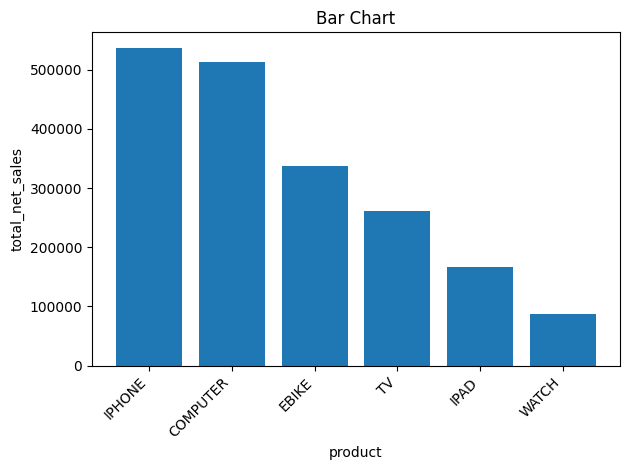

In [22]:

import matplotlib.pyplot as plt
df = con.execute("""
SELECT p.product, SUM(f.net_amount) AS total_net_sales
FROM gold.fact_sales f
JOIN gold.dim_product p ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY total_net_sales DESC
""").df()
plt.figure()
plt.bar(df.iloc[:,0], df.iloc[:,1])
plt.xticks(rotation=45, ha='right')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Bar Chart")
plt.tight_layout()
plt.show()


In [23]:
con.execute("""
SELECT
    p.product,
    ROUND(SUM(f.net_amount), 2) AS total_net_sales
FROM gold.fact_sales f
JOIN gold.dim_product p
  ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY total_net_sales DESC;
""").df()


,product,total_net_sales
0,IPHONE,536162.0
1,COMPUTER,512246.0
2,EBIKE,337414.0
3,TV,260766.0
4,IPAD,166341.0
5,WATCH,86860.0


## Cell 22 — Monthly sales trend

### What are we doing?
We aggregate net sales by month.

### Why are we doing this?
This helps us confirm the designed seasonality in the dataset, especially the stronger sales in November and December 2025.


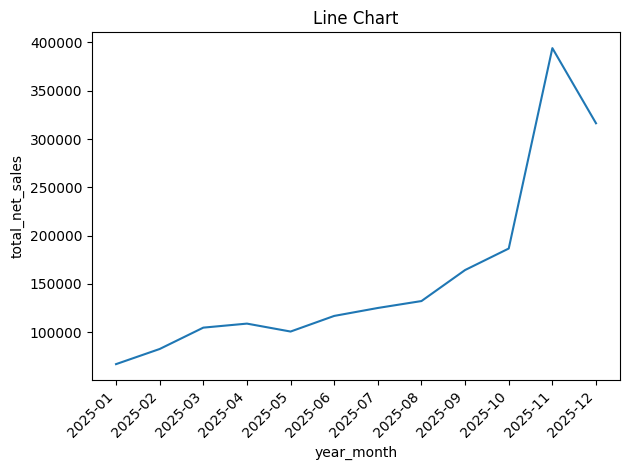

In [24]:

import matplotlib.pyplot as plt
df = con.execute("""
SELECT d.year_month, SUM(f.net_amount) AS total_net_sales
FROM gold.fact_sales f
JOIN gold.dim_date d ON f.date_key = d.date_key
GROUP BY d.year_month
ORDER BY d.year_month
""").df()
plt.figure()
plt.plot(df.iloc[:,0], df.iloc[:,1])
plt.xticks(rotation=45, ha='right')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Line Chart")
plt.tight_layout()
plt.show()


In [ ]:
con.execute("""
SELECT
    d.year_month,
    ROUND(SUM(f.net_amount), 2) AS total_net_sales,
    COUNT(*) AS transaction_count
FROM gold.fact_sales f
JOIN gold.dim_date d
  ON f.date_key = d.date_key
GROUP BY d.year_month
ORDER BY d.year_month;
""").df()


## Cell 23 — Sales by country

### What are we doing?
We calculate sales by customer country.

### Why are we doing this?
This shows how a dimension can be used to slice the fact table by geography.


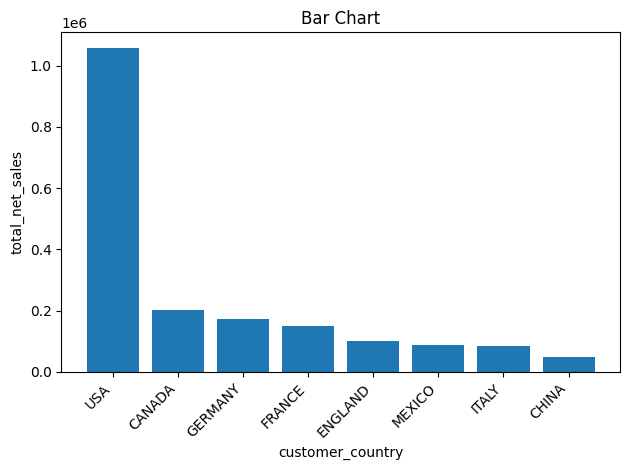

In [25]:

import matplotlib.pyplot as plt
df = con.execute("""
SELECT c.customer_country, SUM(f.net_amount) AS total_net_sales
FROM gold.fact_sales f
JOIN gold.dim_customer c ON f.customer_key = c.customer_key
GROUP BY c.customer_country
ORDER BY total_net_sales DESC
""").df()
plt.figure()
plt.bar(df.iloc[:,0], df.iloc[:,1])
plt.xticks(rotation=45, ha='right')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Bar Chart")
plt.tight_layout()
plt.show()


In [26]:
con.execute("""
SELECT
    c.customer_country,
    ROUND(SUM(f.net_amount), 2) AS total_net_sales,
    COUNT(*) AS transactions
FROM gold.fact_sales f
JOIN gold.dim_customer c
  ON f.customer_key = c.customer_key
GROUP BY c.customer_country
ORDER BY total_net_sales DESC;
""").df()


,customer_country,total_net_sales,transactions
0,USA,1055578.0,665
1,CANADA,200808.5,119
2,GERMANY,171720.0,110
3,FRANCE,150705.5,96
4,ENGLAND,101612.5,67
5,MEXICO,88334.5,56
6,ITALY,83456.5,50
7,CHINA,47573.5,37


## Cell 24 — Top 10 customers by total sales

### What are we doing?
We rank customers by total net sales.

### Why are we doing this?
This query demonstrates customer concentration and helps explain why skewed data matters in analytics.


In [27]:
con.execute("""
SELECT
    c.customer_name,
    c.customer_email,
    ROUND(SUM(f.net_amount), 2) AS total_net_sales,
    COUNT(*) AS transaction_count
FROM gold.fact_sales f
JOIN gold.dim_customer c
  ON f.customer_key = c.customer_key
GROUP BY c.customer_name, c.customer_email
ORDER BY total_net_sales DESC
LIMIT 10;
""").df()


,customer_name,customer_email,total_net_sales,transaction_count
0,Megan Carter,megan.carter83@outlook.com,473044.0,292
1,Kevin Johnson,kevin.johnson34@yahoo.com,200107.0,130
2,Rebecca White,rebecca.white18@proton.me,121285.0,75
3,Ryan Jackson,ryan.jackson94@proton.me,94403.0,46
4,Jack Gonzalez,jack.gonzalez6@yahoo.com,77559.5,50
5,Megan Wilson,megan.wilson17@outlook.com,67835.0,42
6,Grace Jackson,grace.jackson80@outlook.com,46186.0,32
7,Jeffrey Parker,jeffrey.parker39@proton.me,45650.0,32
8,Bruce Taylor,bruce.taylor94@icloud.com,45175.0,27
9,Jason Perez,jason.perez28@outlook.com,42760.0,32


## Cell 25 — Compare IN-STORE vs ON-LINE sales

### What are we doing?
We compare the two sales channels.

### Why are we doing this?
`sale_type` is a useful business attribute even though it is stored in the fact table rather than a separate dimension in this small example.


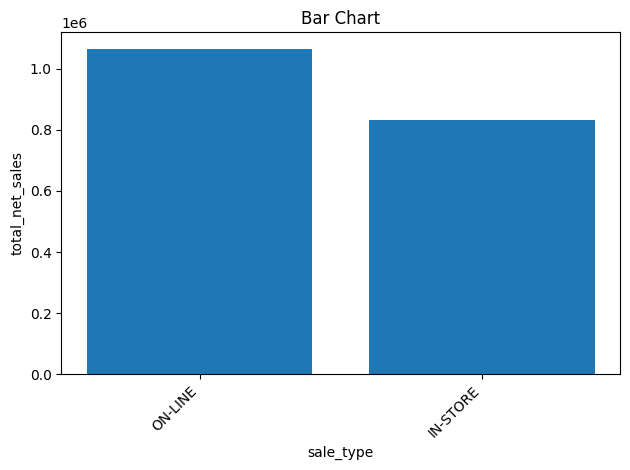

In [28]:

import matplotlib.pyplot as plt
df = con.execute("""
SELECT sale_type, SUM(net_amount) AS total_net_sales
FROM gold.fact_sales
GROUP BY sale_type
""").df()
plt.figure()
plt.bar(df.iloc[:,0], df.iloc[:,1])
plt.xticks(rotation=45, ha='right')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Bar Chart")
plt.tight_layout()
plt.show()


In [29]:
con.execute("""
SELECT
    sale_type,
    COUNT(*) AS transactions,
    ROUND(SUM(net_amount), 2) AS total_net_sales,
    ROUND(AVG(net_amount), 2) AS avg_net_sale
FROM gold.fact_sales
GROUP BY sale_type
ORDER BY total_net_sales DESC;
""").df()


,sale_type,transactions,total_net_sales,avg_net_sale
0,ON-LINE,645,1065955.0,1652.64
1,IN-STORE,555,833834.0,1502.40


## Cell 26 — Average discount by product

### What are we doing?
We analyze average discount by product.

### Why are we doing this?
This shows how measures in the fact table can be studied across dimensions.


In [30]:
con.execute("""
SELECT
    p.product,
    ROUND(AVG(f.discount), 2) AS avg_discount,
    ROUND(SUM(f.discount), 2) AS total_discount_given
FROM gold.fact_sales f
JOIN gold.dim_product p
  ON f.product_key = p.product_key
GROUP BY p.product
ORDER BY avg_discount DESC;
""").df()


,product,avg_discount,total_discount_given
0,EBIKE,146.05,18986.0
1,COMPUTER,126.86,30954.0
2,IPHONE,86.76,29238.0
3,TV,62.30,12834.0
4,IPAD,58.11,8659.0
5,WATCH,40.22,5390.0


## Cell 27 — Find the busiest store location

### What are we doing?
We calculate transaction count and sales by store location.

### Why are we doing this?
This is another example of slicing the fact table with a dimension.


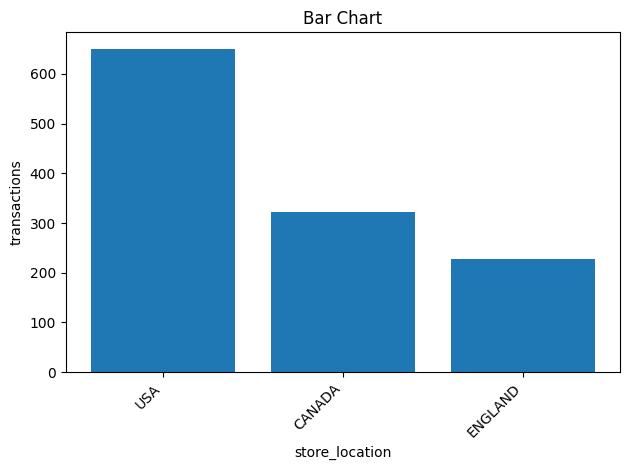

In [31]:

import matplotlib.pyplot as plt
df = con.execute("""
SELECT s.store_location, COUNT(*) AS transactions
FROM gold.fact_sales f
JOIN gold.dim_store s ON f.store_key = s.store_key
GROUP BY s.store_location
ORDER BY transactions DESC
""").df()
plt.figure()
plt.bar(df.iloc[:,0], df.iloc[:,1])
plt.xticks(rotation=45, ha='right')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.title("Bar Chart")
plt.tight_layout()
plt.show()


In [32]:
con.execute("""
SELECT
    s.store_location,
    COUNT(*) AS transactions,
    ROUND(SUM(f.net_amount), 2) AS total_net_sales
FROM gold.fact_sales f
JOIN gold.dim_store s
  ON f.store_key = s.store_key
GROUP BY s.store_location
ORDER BY transactions DESC;
""").df()


,store_location,transactions,total_net_sales
0,USA,651,1004934.0
1,CANADA,322,537185.5
2,ENGLAND,227,357669.5


## Cell 28 — Final explanation

### What did we learn?

We built a full teaching example of Medallion Architecture:

### Bronze
- landed raw source data
- preserved the ingestion step

### Silver
- standardized text
- typed columns
- added derived business measures
- ran validation checks

### Gold
- created dimensions
- created a fact table
- ran analytical SQL

This pattern scales from classroom notebooks to real modern data platforms.
